# AI for Finance [IE471]
##  Hands-on Practice on Financial AI Session #3-2

In [1]:
# Import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import nltk
import re
from textblob import TextBlob
%matplotlib inline
import seaborn as sns

In [2]:
# Read in and preview 'cleaned_data.csv'
tweets = pd.read_csv('cleaned_data.csv')
tweets = tweets.iloc[:, [0, 1, 4]]
tweets.head()

,id,date,cleaned_tweet
0,1212450794705969152,2020-01-02,fun fact audi register e tron netherlands su...
1,1212450579634626560,2020-01-02,mf stock watch shit go damn year miss curve
2,1212450337543602177,2020-01-02,icannot enough june th within day low reply c...
3,1212450309131227141,2020-01-02,gain momentum taiwan ownerstwn taiwan
4,1212449703318753280,2020-01-02,schuldensuehner extrapolate number another two...


In [3]:
# Look at tesla_tweets data types

tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113741 entries, 0 to 113740
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             113741 non-null  int64 
 1   date           113741 non-null  object
 2   cleaned_tweet  109112 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.6+ MB


In [4]:
# Convert date_time column into datetime stamp

tweets.date = pd.to_datetime(tweets.date)
tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113741 entries, 0 to 113740
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   id             113741 non-null  int64         
 1   date           113741 non-null  datetime64[ns]
 2   cleaned_tweet  109112 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.6+ MB


In [5]:
# Check for null values

tweets.isnull().sum()

,0
id,0
date,0
cleaned_tweet,4629


In [6]:
# Drop null values

tweets = tweets.dropna()

### 1. Calculate Sentiment Score with TextBlob

In [7]:
# Use TextBlob to get sentiment scores

tweets['sentiment'] = tweets.apply(lambda row: TextBlob(row.cleaned_tweet).sentiment[0], axis=1)
tweets.head()

,id,date,cleaned_tweet,sentiment
0,1212450794705969152,2020-01-02,fun fact audi register e tron netherlands su...,0.15
1,1212450579634626560,2020-01-02,mf stock watch shit go damn year miss curve,-0.20
2,1212450337543602177,2020-01-02,icannot enough june th within day low reply c...,0.20
3,1212450309131227141,2020-01-02,gain momentum taiwan ownerstwn taiwan,0.00
4,1212449703318753280,2020-01-02,schuldensuehner extrapolate number another two...,0.75


In [8]:
# Preview how sentiment scores differ on different tweets

pd.options.display.max_colwidth = 300
random_subset = tweets.sample(n=10)
random_subset = random_subset.drop(columns=['id', 'date'])
random_subset.rename(columns={'tweet':'Original Tweet'})
random_subset = random_subset.rename(columns={'tweet': 'Original Tweet', 'cleaned_tweet': 'Cleaned Tweet', 'sentiment':'TextBlob Sentiment'})
random_subset.head(10)

,Cleaned Tweet,TextBlob Sentiment
28837,wave elliotwaves,0.000000
38047,nottheworstkid joshuaefuller anonyx elonmusk ceo knock company stock price acceptable volatility tell thousand furlough employee sell share pay rent,0.000000
67562,inside day acb amrn cgc chgg chwy ea fb googl i mdlz mrk mu net nflx nio pfe snap stz tlry tsn wing,0.000000
47732,small account trade rh crwd straight pre market note watch today recap like amp subscribe,-0.025000
86253,sawyermerritt get ta ponder analyst agenda talk bout crazy price target fool crazy,-0.600000
21578,mar wednesday close,0.000000
14206,sjosephburns greektrader exception investor invest go less year afford sell share enjoy nice model call cash recycle life short make money nice also need enjoy,0.305556
70235,like,0.000000
25780,popular stock apple inc aapl inc,0.600000
37122,tradewithninja thought think short term drop rest market might come top post recession sell share wait jump back,0.166667


In [9]:
tweets.shape

(109112, 4)

### 2. Frequency Analysis

<ipython-input-10-a7ce7508a42d>:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=14)


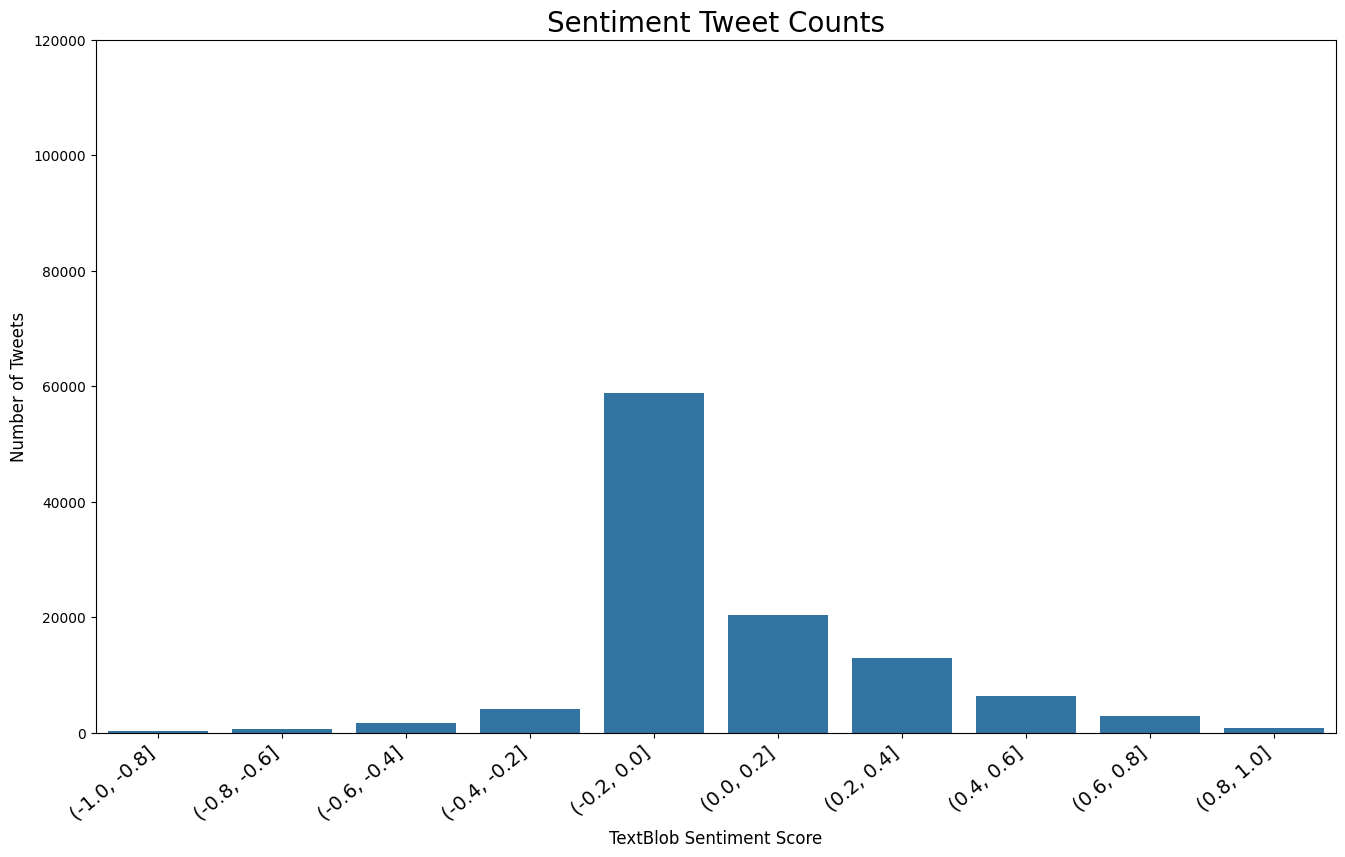

In [10]:
# View count of tweets for binned sentiment

bins = [-1.0, -0.8, -0.6, -.4, -.2, 0, 0.2, 0.4, 0.6, 0.8, 1]
tweets['binned'] = pd.cut(tweets['sentiment'], bins)
plt.figure(figsize=(16,9))
ax = sns.countplot(x=tweets['binned'])
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_xlabel('TextBlob Sentiment Score', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=14)
ax.set_title("Sentiment Tweet Counts", fontsize=20)
ax.set_ylim(0, 120000)
plt.show()

### 3. Calculate Daily Sentiment

In [11]:
daily_sentiment = tweets[['date', 'sentiment']]
daily_sentiment.head()

,date,sentiment
0,2020-01-02,0.15
1,2020-01-02,-0.20
2,2020-01-02,0.20
3,2020-01-02,0.00
4,2020-01-02,0.75


In [12]:
daily_sentiment = daily_sentiment.resample('D', on='date').mean()
daily_sentiment.head()

,sentiment
date,
2020-01-01,0.099938
2020-01-02,0.111398
2020-01-03,0.073760
2020-01-04,0.083606
2020-01-05,0.086658


<ipython-input-13-908706c01cef>:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=12)


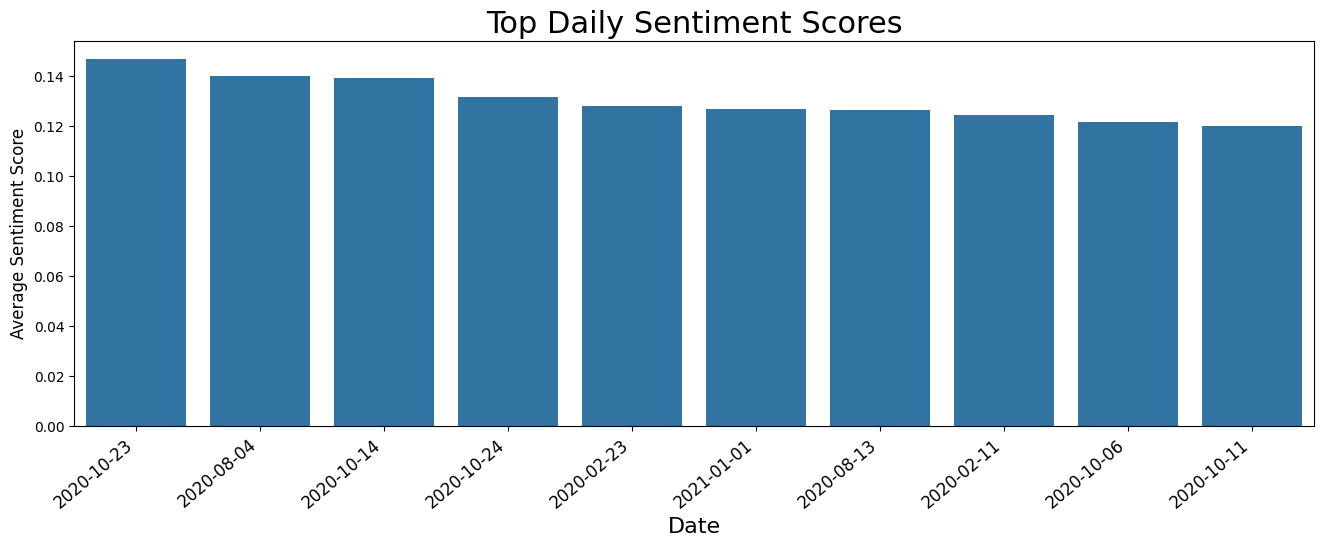

In [13]:
# Find the days with the highest sentiment_2

freq_df = daily_sentiment.nlargest(columns="sentiment", n = 10)
plt.figure(figsize=(16,5))
ax = sns.barplot(data=freq_df, x= freq_df.index.date, y = freq_df['sentiment'])
ax.set_ylabel('Average Sentiment Score', fontsize=12)
ax.set_xlabel('Date', fontsize=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=12)
ax.set_title('Top Daily Sentiment Scores', fontsize=22)
plt.show()

<ipython-input-14-c062842c9ce7>:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=12)


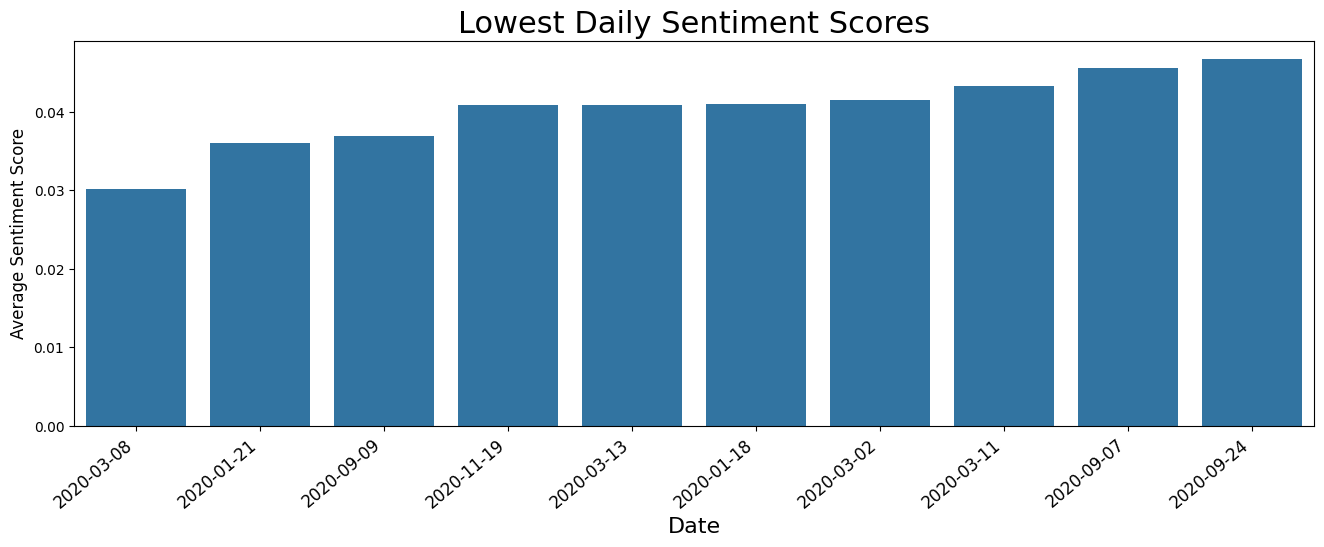

In [14]:
freq_df = daily_sentiment.nsmallest(columns="sentiment", n = 10)
plt.figure(figsize=(16,5))
ax = sns.barplot(data=freq_df, x= freq_df.index.date, y = freq_df['sentiment'])
ax.set_ylabel('Average Sentiment Score', fontsize=12)
ax.set_xlabel('Date', fontsize=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=12)
ax.set_title('Lowest Daily Sentiment Scores', fontsize=22)

plt.show()

### 4. Remove Tweets with Sentiment Scores of 0

In [15]:
remove_s1_0 = tweets.copy()
remove_s1_0.head()

,id,date,cleaned_tweet,sentiment,binned
0,1212450794705969152,2020-01-02,fun fact audi register e tron netherlands sux combine obviously order magnitude,0.15,"(0.0, 0.2]"
1,1212450579634626560,2020-01-02,mf stock watch shit go damn year miss curve,-0.20,"(-0.4, -0.2]"
2,1212450337543602177,2020-01-02,icannot enough june th within day low reply charts never short lol,0.20,"(0.0, 0.2]"
3,1212450309131227141,2020-01-02,gain momentum taiwan ownerstwn taiwan,0.00,"(-0.2, 0.0]"
4,1212449703318753280,2020-01-02,schuldensuehner extrapolate number another two year consider amp occur ice company scramble survive look like successful,0.75,"(0.6, 0.8]"


In [16]:
# Check how many tweets had sentiment scores of 0
print('There are ' + str((remove_s1_0.sentiment == 0).sum()) + ' tweets with a Sentiment Score of 0')

There are 48897 tweets with a Sentiment Score of 0


In [17]:
# Remove tweets with 0 for sentiment_2 scores
remove_0 = tweets.copy()
remove_0 = remove_0.rename(columns={'sentiment':'s_no_0'})
remove_0 = remove_0[remove_0.s_no_0 != 0]
(remove_0.s_no_0 == 0).sum()

np.int64(0)

In [18]:
# Replace code
# remove_0 = remove_0.groupby(['date'], as_index = False).mean()

# 1. 숫자형 컬럼만 필터링 (drop non-numeric columns)
numeric_cols = remove_0.select_dtypes(include=['number']).columns.tolist()

# 2. 'date'와 숫자형 열만 포함한 데이터프레임 생성
remove_0_groupable = remove_0[['date'] + numeric_cols]

# 3. 날짜별 평균 계산
remove_0 = remove_0_groupable.groupby(['date'], as_index=False).mean()

In [19]:
# Check that there are no null values

remove_0.isnull().sum()

,0
date,0
id,0
s_no_0,0


In [20]:
# Add updated columns back to early_tweets dataframe
daily_sentiment['sentiment_final'] = remove_0.s_no_0.values
daily_sentiment.index.names = ['Date']
daily_sentiment.head()

,sentiment,sentiment_final
Date,,
2020-01-01,0.099938,0.154961
2020-01-02,0.111398,0.161528
2020-01-03,0.073760,0.128297
2020-01-04,0.083606,0.144796
2020-01-05,0.086658,0.132267


### 5. Save Sentiment Analysis Results

In [22]:
daily_sentiment.to_csv('daily_sentiment_scores.csv')